In [ ]:
!unzip data_case2_final.zip

# Importing Libraries

In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv3D, MaxPooling3D, Flatten, Dense, Dropout, BatchNormalization, Input, Concatenate
from tensorflow.keras.optimizers import Adam

# Defining image specifications

In [ ]:
num_frames = 21
img_height = 60  # Modify according to your image dimensions
img_width = 80   # Modify according to your image dimensions
num_channels = 3  # For RGB, use 1 for grayscale
input_shape = (num_frames, img_height, img_width, num_channels)

# Reading labels

In [ ]:
velocity_labels = pd.read_csv("/content/data_case2_final/simulation_data.csv")
velocity_labels.head(10)

,v1 (m/s),v2 (m/s),Surface Tension (N/m),v1/v2,Weber Number,Capillary Number
0,0.005,0.0005,0.001,10.0,0.060750,0.000620
1,0.005,0.0005,0.002,10.0,0.030375,0.000310
2,0.005,0.0005,0.003,10.0,0.020250,0.000207
3,0.005,0.0005,0.004,10.0,0.015187,0.000155
4,0.005,0.0005,0.005,10.0,0.012150,0.000124
5,0.005,0.0005,0.006,10.0,0.010125,0.000103
6,0.005,0.0005,0.007,10.0,0.008679,0.000089
7,0.005,0.0005,0.008,10.0,0.007594,0.000077
8,0.005,0.0005,0.009,10.0,0.006750,0.000069
9,0.005,0.0005,0.010,10.0,0.006075,0.000062


In [ ]:
temp = np.array(velocity_labels)
size = temp.shape[0]
print(size)
temp2 = temp[:, 0:3]
print(temp2.shape)

1000
(1000, 3)


# Analyzing relationships between labels

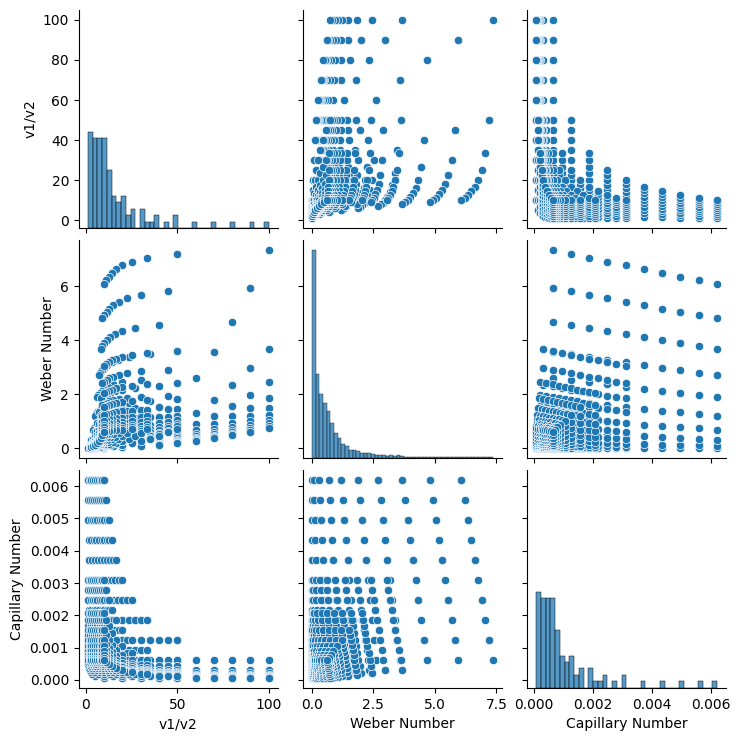

In [ ]:
df = velocity_labels.iloc[:, -3:]
sns.pairplot(df)
plt.show()

# Treating skewness

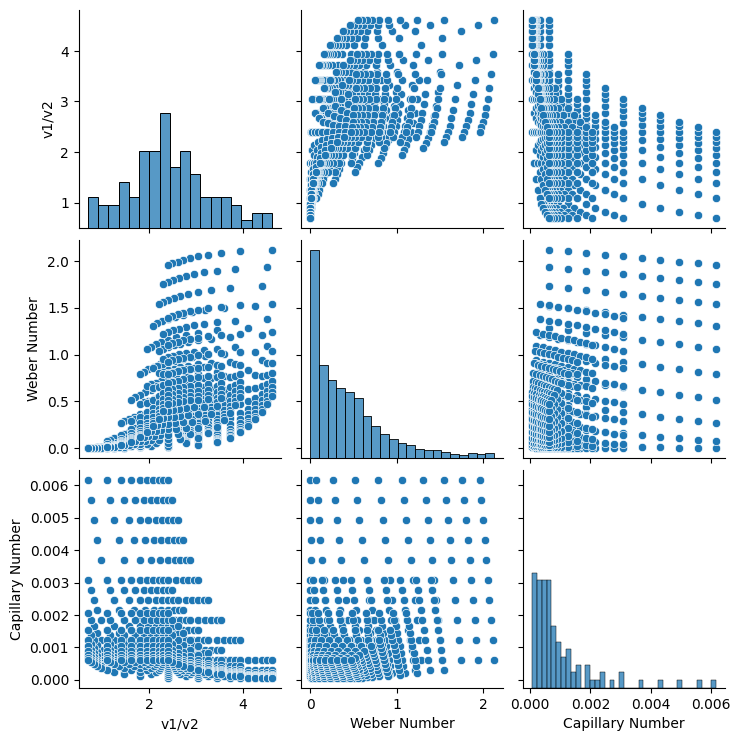

In [ ]:
df_transformed = df.copy()
for column in df.columns:
  df_transformed[column]= np.log(df[column] + 1)
sns.pairplot(df_transformed)
plt.show()

# Normalising data

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scalers = []
for column in df_transformed.columns:
    scaler = MinMaxScaler()
    df_transformed[column] = scaler.fit_transform(df_transformed[[column]])
    scalers.append(scaler)
print(df_transformed.head())

      v1/v2  Weber Number  Capillary Number
0  0.434666      0.027788          0.091162
1  0.434666      0.014099          0.040523
2  0.434666      0.009446          0.023640
3  0.434666      0.007102          0.015197
4  0.434666      0.005690          0.010132


# Converting labels to numpy array

In [ ]:
y = df_transformed.to_numpy()
y.shape

(1000, 3)

# Reading image data

In [ ]:
image_folder = '/content/data_case2_final'

In [ ]:
s = ['001','011','021','031','041','051','061','071','081','091','101','111','121','131','141','151','161','171','181','191','201']

In [ ]:
def load_image_sequence(image_folder, start_idx, num_frames,s):
    images = []
    for i in range(num_frames):
        idx = start_idx + 1
        if idx%100==0:
          a = idx//100
          b = 10
          c = 10
        elif idx%10==0:
          a = (idx//100)%100 + 1
          b = (idx//10)%10
          c = 10
        else:
          a = (idx//100)%100 + 1
          b = (idx//10)%10 + 1
          c = idx%10
        img_path = os.path.join(image_folder, f'{str(idx).zfill(4)}_v1_{str(a).zfill(3)}_v2_{str(b).zfill(3)}_tension_{str(c).zfill(3)}{s[i]}.png')  # Modify if using a different format
        img = Image.open(img_path)
        #img = img.convert('L') #Grayscaling image
        img = img.resize((img_width,img_height))
        img_array = np.array(img)
        # if img_array.shape[-1] != num_channels:  # Convert to RGB if necessary
        #     img_array = np.repeat(img_array[..., np.newaxis], num_channels, -1)
        images.append(img_array)
    return np.stack(images, axis=0)

In [ ]:
X = []

In [ ]:
for start_idx in range(size):
    sequence = load_image_sequence(image_folder, start_idx, num_frames,s)
    X.append(sequence)

In [ ]:
X = np.array(X)  # Shape: (num_samples, num_frames, img_height, img_width, num_channels)

In [ ]:
X.shape

(1000, 21, 60, 80, 3)

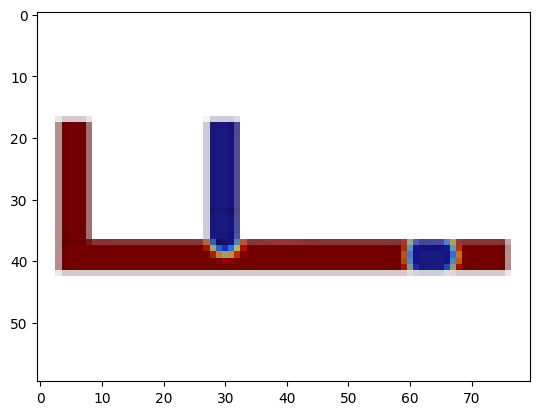

In [ ]:
plt.imshow(X[574][15])

In [ ]:
X = X.astype('float32') / 255.0 #Normalise image data

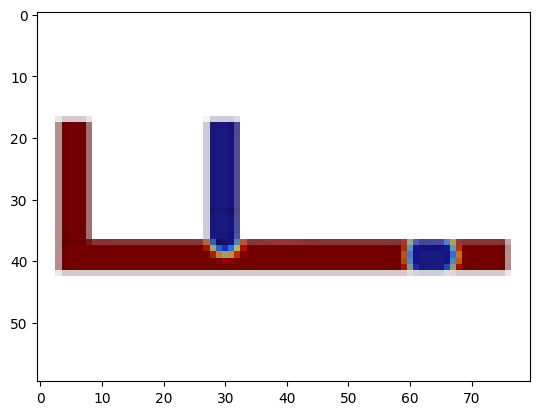

In [ ]:
plt.imshow(X[574][15])

# Train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# Building 3D CNN model

In [ ]:
# Build the 3D CNN model
model = Sequential()

# 3D Convolutional Layer 1
model.add(Conv3D(filters=16, kernel_size=(3, 3, 3), activation='relu', input_shape=(num_frames, img_height, img_width, num_channels)))
model.add(MaxPooling3D(pool_size=(1, 2, 2)))

# 3D Convolutional Layer 2
model.add(Conv3D(filters=32, kernel_size=(3, 3, 3), activation='relu'))
model.add(MaxPooling3D(pool_size=(1, 2, 2)))

# Flatten the output
model.add(Flatten())

# Dense Layers
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))

# Output layer for three independent labels
model.add(Dense(3))

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                      │ (None, 19, 58, 78, 16)      │           1,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling3d (MaxPooling3D)         │ (None, 19, 29, 39, 16)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_1 (Conv3D)                    │ (None, 17, 27, 37, 32)      │          13,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling3d_1 (MaxPooling3D)       │ (None, 17, 13, 18, 32)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 127296)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       8,147,008 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,164,355 (31.14 MB)

 Trainable params: 8,164,355 (31.14 MB)

 Non-trainable params: 0 (0.00 B)

# Fitting model on train data

In [ ]:
history = model.fit(X_train, y_train, epochs=30, batch_size=2)

Epoch 1/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 2.0454 - mae: 0.3353
Epoch 2/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0123 - mae: 0.0746
Epoch 3/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0085 - mae: 0.0652
Epoch 4/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0075 - mae: 0.0587
Epoch 5/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0052 - mae: 0.0477
Epoch 6/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0043 - mae: 0.0428
Epoch 7/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0046 - mae: 0.0454
Epoch 8/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0034 - mae: 0.0397
Epoch 9/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0039 - mae: 0.0430
Epoch 10/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0045 - mae: 0.0463
Epoch 11/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0035 - mae: 0.0408
Epoch 12/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0037 - mae: 0.0415
Epoch 13/30
425

# Calculating R2 score for train data

In [ ]:
predictions = model.predict(X_train)
predictions.shape

27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step


(850, 3)

In [ ]:
r2_scores = []
for i in range(3):  # Loop over each output (column)
    r2 = r2_score(y_train[:,i], predictions[:,i])
    r2_scores.append(r2)
    print(f"R² score for output {i + 1}: {r2}")

# R² scores for all outputs
print("R² scores for all outputs:", r2_scores)

R² score for output 1: 0.9864085043492941
R² score for output 2: 0.9754189262576495
R² score for output 3: 0.9468829928195236
R² scores for all outputs: [0.9864085043492941, 0.9754189262576495, 0.9468829928195236]


# Calculating R2 score for test data

In [ ]:
predictions2 = model.predict(X_test)
predictions2.shape

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 263ms/step


(150, 3)

In [ ]:
r2_scores = []
for i in range(3):  # Loop over each output (column)
    r2 = r2_score(y_test[:,i], predictions2[:,i])
    r2_scores.append(r2)
    print(f"R² score for output {i + 1}: {r2}")

# R² scores for all outputs
print("R² scores for all outputs:", r2_scores)

R² score for output 1: 0.9693266070697194
R² score for output 2: 0.92075549843047
R² score for output 3: 0.9357772592352885
R² scores for all outputs: [0.9693266070697194, 0.92075549843047, 0.9357772592352885]


# Making predictions using model

In [ ]:
y_pred = model.predict(X)
y_pred_original = np.zeros_like(y_pred)
y_true_original = np.zeros_like(y)
for i, scaler in enumerate(scalers):
   y_pred_original[:, i] = scaler.inverse_transform(y_pred[:, i].reshape(-1, 1)).flatten()
   y_true_original[:, i] = scaler.inverse_transform(y[:, i].reshape(-1, 1)).flatten()
y_pred_original = np.exp(y_pred_original) - 1
y_true_original = np.exp(y_true_original) - 1
data = np.hstack((y_true_original, y_pred_original))
columns = ['Actual Flow Rate Ratio', 'Actual Weber No', 'Actual Capillary No',
           'Predicted Flow Rate Ratio', 'Predicted Weber No', 'Predicted Capillary No']
results_df = pd.DataFrame(data, columns=columns)
results_df.to_csv("Actual_vs_Predicted.csv", index=False)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


In [ ]:
results_df.head(10)

,Actual Flow Rate Ratio,Actual Weber No,Actual Capillary No,Predicted Flow Rate Ratio,Predicted Weber No,Predicted Capillary No
0,10.0,0.060750,0.000620,11.477520,0.075422,0.000332
1,10.0,0.030375,0.000310,11.493048,0.031112,0.000289
2,10.0,0.020250,0.000207,13.113563,0.003248,0.000216
3,10.0,0.015187,0.000155,13.181526,-0.013027,0.000202
4,10.0,0.012150,0.000124,11.452197,-0.009488,0.000242
5,10.0,0.010125,0.000103,10.604858,-0.006840,0.000264
6,10.0,0.008679,0.000089,11.377886,-0.021405,0.000234
7,10.0,0.007594,0.000077,10.783127,-0.008028,0.000252
8,10.0,0.006750,0.000069,11.503998,-0.013193,0.000231
9,10.0,0.006075,0.000062,11.541913,-0.007697,0.000229


# Visualisation of actual vs predicted values

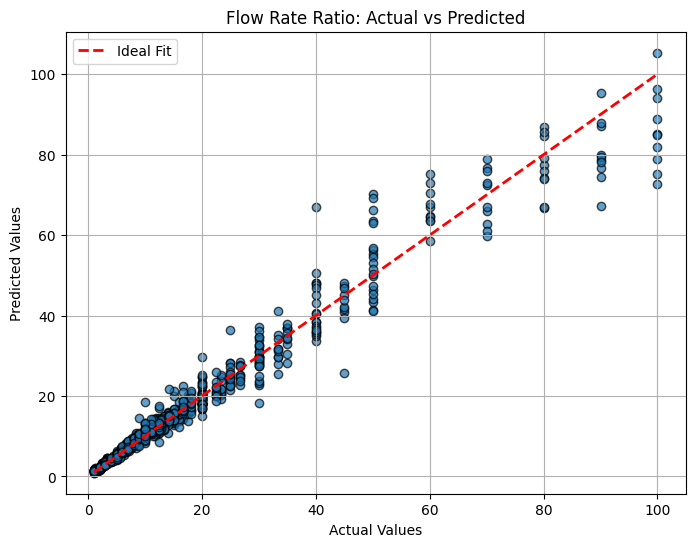

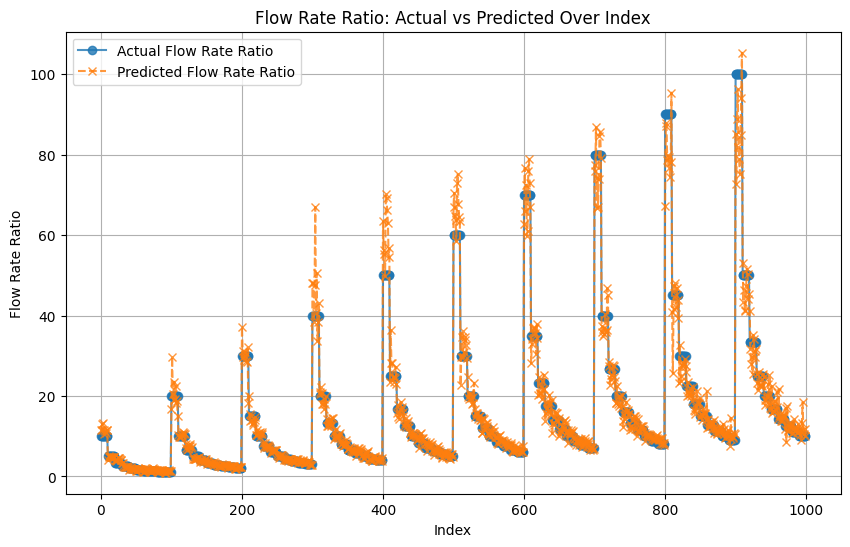

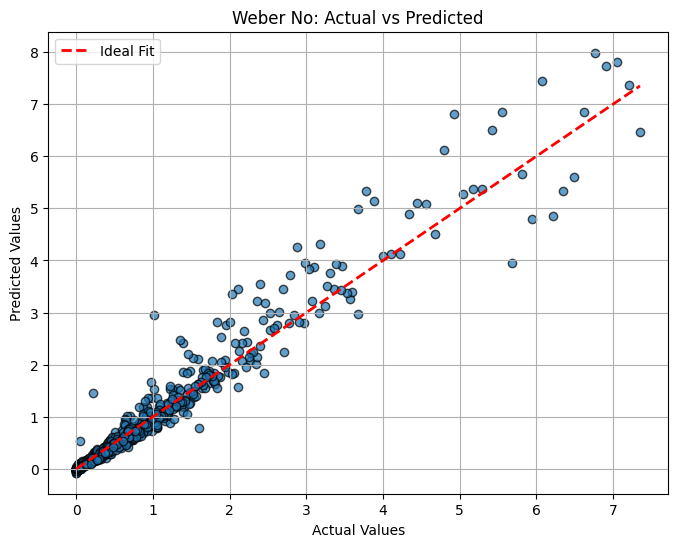

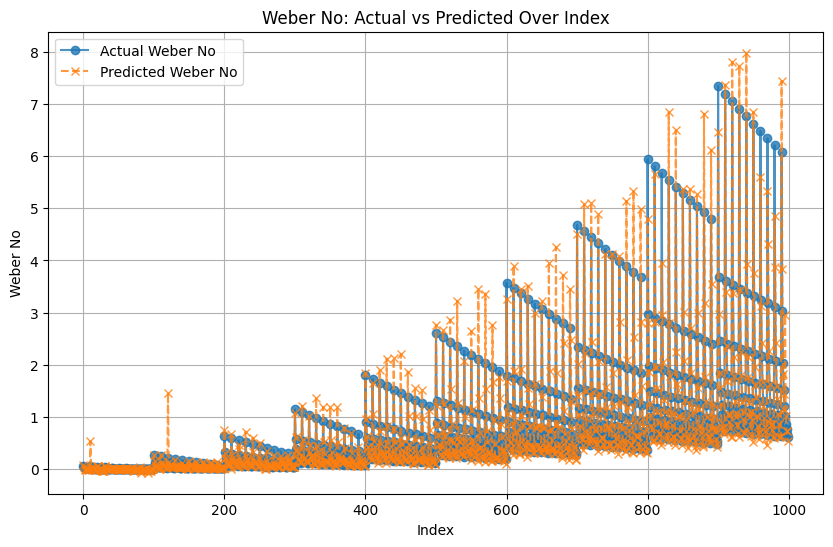

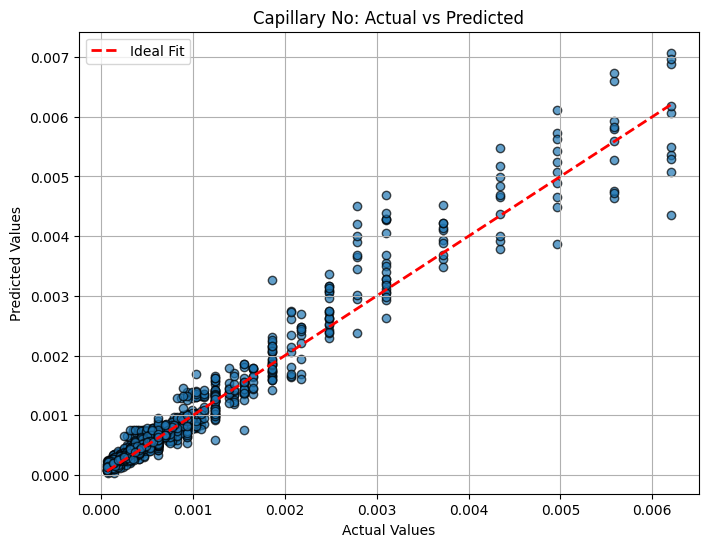

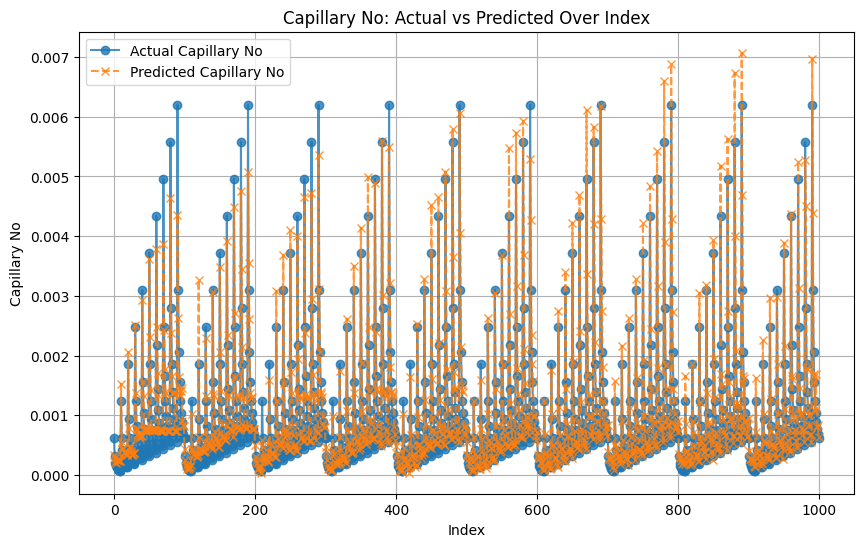

In [ ]:
# Assuming results_df is your DataFrame with the specified columns
columns = ['Actual Flow Rate Ratio', 'Actual Weber No', 'Actual Capillary No',
           'Predicted Flow Rate Ratio', 'Predicted Weber No', 'Predicted Capillary No']

# Plotting each pair of actual vs predicted values
parameters = ['Flow Rate Ratio', 'Weber No', 'Capillary No']

for i, parameter in enumerate(parameters):
    actual_col = f'Actual {parameter}'
    predicted_col = f'Predicted {parameter}'

    # Scatter Plot
    plt.figure(figsize=(8, 6))
    plt.scatter(results_df[actual_col], results_df[predicted_col], alpha=0.7, edgecolor='k')
    plt.plot([results_df[actual_col].min(), results_df[actual_col].max()],
             [results_df[actual_col].min(), results_df[actual_col].max()], 'r--', lw=2, label='Ideal Fit')
    plt.title(f'{parameter}: Actual vs Predicted')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Line Plot
    plt.figure(figsize=(10, 6))
    plt.plot(results_df[actual_col], label=f'Actual {parameter}', marker='o', linestyle='-', alpha=0.8)
    plt.plot(results_df[predicted_col], label=f'Predicted {parameter}', marker='x', linestyle='--', alpha=0.8)
    plt.title(f'{parameter}: Actual vs Predicted Over Index')
    plt.xlabel('Index')
    plt.ylabel(parameter)
    plt.legend()
    plt.grid(True)
    plt.show()


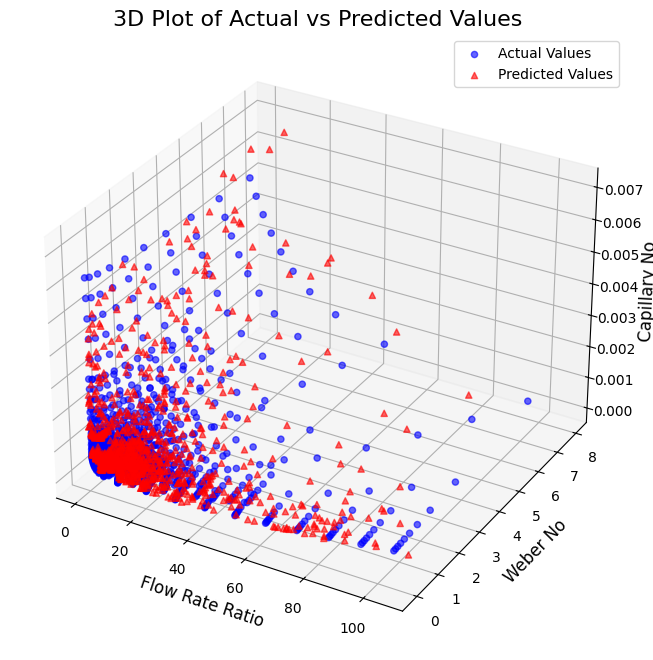

In [37]:
from mpl_toolkits.mplot3d import Axes3D

# Assuming results_df contains the actual and predicted values
columns = ['Actual Flow Rate Ratio', 'Actual Weber No', 'Actual Capillary No',
           'Predicted Flow Rate Ratio', 'Predicted Weber No', 'Predicted Capillary No']

# Extract data
actual_values = results_df[['Actual Flow Rate Ratio', 'Actual Weber No', 'Actual Capillary No']].values
predicted_values = results_df[['Predicted Flow Rate Ratio', 'Predicted Weber No', 'Predicted Capillary No']].values

# 3D Scatter Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot actual values
ax.scatter(actual_values[:, 0], actual_values[:, 1], actual_values[:, 2],
           c='blue', marker='o', label='Actual Values', alpha=0.6)

# Plot predicted values
ax.scatter(predicted_values[:, 0], predicted_values[:, 1], predicted_values[:, 2],
           c='red', marker='^', label='Predicted Values', alpha=0.6)

# Set labels
ax.set_title('3D Plot of Actual vs Predicted Values', fontsize=16)
ax.set_xlabel('Flow Rate Ratio', fontsize=12)
ax.set_ylabel('Weber No', fontsize=12)
ax.set_zlabel('Capillary No', fontsize=12)

# Add legend
ax.legend()

# Show plot
plt.show()




**--------------------------------------------------------------------------------------------------------------**



# Save the model

In [ ]:
model.save('3d_cnn_velocity_model_case2.keras')